In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
LABELS = ['Normal', 'Fraud']

data = pd.read_csv('creditcard.csv')
head = data.head()
print(head)

   Time        V1        V2        V3        V4        V5        V6        V7        V8        V9  ...       V21       V22       V23       V24       V25       V26       V27       V28  Amount  Class
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599  0.098698  0.363787  ...  -0.018307  0.277838 -0.110474  0.066928  0.128539 -0.189115  0.133558 -0.021053  149.62      0
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803  0.085102 -0.255425  ...  -0.225775 -0.638672  0.101288 -0.339846  0.167170  0.125895 -0.008983  0.014724    2.69      0
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461  0.247676 -1.514654  ...   0.247998  0.771679  0.909412 -0.689281 -0.327642 -0.139097 -0.055353 -0.059752  378.66      0
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609  0.377436 -1.387024  ...  -0.108300  0.005274 -0.190321 -1.175575  0.647376 -0.221929  0.062723  0.061458  123.50      0
4     

In [2]:
columns = data.columns.tolist()
columns = [c for c in columns if c not in ['Class']]
print(columns)

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [3]:
target = 'Class'
X = data[columns]
y = data[target]

print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [4]:
print("------")
print(data.isnull().count())
print("------")

------
Time      284807
V1        284807
V2        284807
V3        284807
V4        284807
V5        284807
V6        284807
V7        284807
V8        284807
V9        284807
V10       284807
V11       284807
V12       284807
V13       284807
V14       284807
V15       284807
V16       284807
V17       284807
V18       284807
V19       284807
V20       284807
V21       284807
V22       284807
V23       284807
V24       284807
V25       284807
V26       284807
V27       284807
V28       284807
Amount    284807
Class     284807
dtype: int64
------


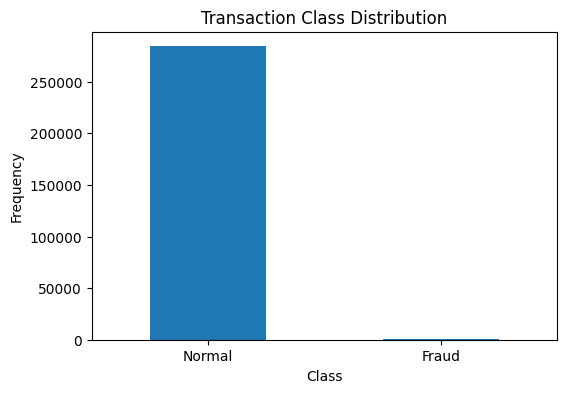

In [5]:
count_classes = pd.Series(y).value_counts()
count_classes.plot(kind='bar', rot=0)
plt.title("Transaction Class Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel('Frequency')
plt.show()

In [6]:
fraud = data[data['Class'] == 1]
normal = data[data['Class'] == 0]
print("Fraud", fraud.shape)
print("Normal", normal.shape)

Fraud (492, 31)
Normal (284315, 31)


In [7]:
from imblearn.under_sampling import RandomUnderSampler, NearMiss

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)
print(X_res.shape)
print(y_res.shape)

(984, 30)
(984,)


In [8]:
nm1 = NearMiss(version=1)
X_res1, y_res1 = nm1.fit_resample(X, y)
print(X_res1.shape)
print(y_res1.shape)
print(X_res1.head(5))

(984, 30)
(984,)
      Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22       V23       V24       V25       V26       V27       V28  Amount
0  76866.0  1.257227  0.408096  0.319266  0.685011 -0.302937 -1.052552  0.136991 -0.245655 -0.079491 -0.304453  0.055638  0.627844  0.968874 -0.435499  1.012926  0.445284 -0.049622 -0.388480 -0.201395 -0.033053 -0.279430 -0.770134  0.119789  0.360130  0.241921  0.092261 -0.018228  0.032361    1.78
1  76868.0  1.254775  0.375340  0.311959  0.691077 -0.343494 -1.065252  0.110222 -0.222721 -0.017278 -0.292722 -0.010006  0.409479  0.553968 -0.352550  1.058069  0.463211 -0.023915 -0.339299 -0.200980 -0.057911 -0.283275 -0.803506  0.124643  0.354395  0.226835  0.093208 -0.021100  0.031686    2.69
2  76870.0 -1.050697  1.500753  0.846326 -0.282956  0.059866 -0.561182  0.484517  0.18

In [9]:
nm2 = NearMiss(version=2)
X_res1, y_res1 = nm2.fit_resample(X, y)
print(X_res1.shape)
print(y_res1.shape)
print(X_res1.head(5))

(984, 30)
(984,)
      Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22       V23       V24       V25       V26       V27       V28  Amount
0  85218.0 -1.731864  0.562746  1.387614 -1.814780 -0.439519 -0.666038 -0.015537  0.299804 -1.486124  0.071418 -0.073487 -0.035063  1.185848 -0.293850  0.351367  1.110768  0.370275 -2.137941 -0.208536 -0.008267 -0.049139 -0.298044  0.120919  0.069443  0.308891 -0.584395 -0.229966  0.123738   19.95
1  85218.0 -1.629153  0.300867  0.622990  0.567468  0.641691 -0.960184 -0.329045  0.452075 -0.777520 -0.191821  1.149540  0.937425  0.683398  0.069235  0.529188  0.526904  0.015553  0.527452  0.996996  0.066201 -0.133779 -0.510669 -0.345254  0.021245 -0.731109  0.090673  0.327665 -0.150443    2.28
2  85218.0  1.203377  0.149740  0.603745  0.560316 -0.591890 -0.804040 -0.090672 -0.02

In [10]:
nm3 = NearMiss(version=3)
X_res1, y_res1 = nm3.fit_resample(X, y)
print(X_res1.shape)
print(y_res1.shape)
print(X_res1.head(5))

(984, 30)
(984,)
     Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22       V23       V24       V25       V26       V27       V28   Amount
0  4431.0 -1.070820  0.457695 -0.711720  0.530320  1.973213  3.960238  0.530366  1.131509  0.196337 -0.948813  0.301321 -2.646910  1.558487  2.151652 -0.238623 -0.402932  0.660839  0.712910  1.126022  0.533360  0.044373 -0.192445  0.229718  0.941406  0.479095 -0.181232 -0.094751  0.029936   226.00
1  4492.0  0.813421 -0.748426  1.340310  0.640720 -1.525057 -0.637926 -0.455720 -0.174873  2.179720 -0.875904  0.937082 -1.380268  2.562037  0.879250 -0.557344 -0.041084  0.805459 -0.364560 -0.239567  0.323360 -0.107095 -0.260154 -0.041856  0.967640 -0.021689  0.895382 -0.090244  0.050600   200.00
2  4521.0  1.107345 -1.143295 -0.242243 -1.613373 -1.158648 -1.356396 -0.053526 -0.508

34.8016658766686
-113.743306711146


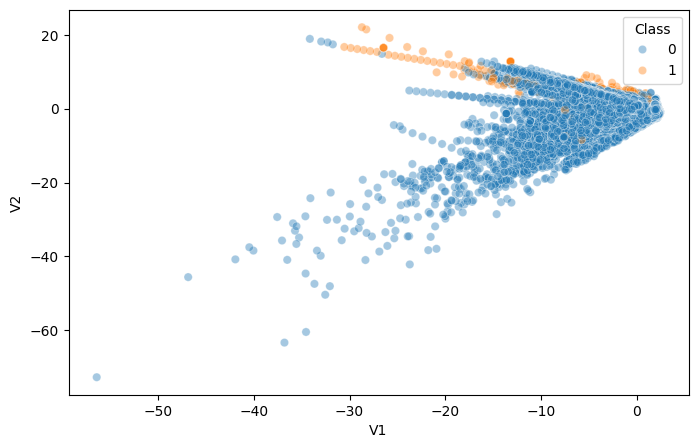

In [11]:
import seaborn as sns

print(data[columns[5]].max())
print(data[columns[5]].min())
sns.scatterplot(x=columns[1], y=columns[2], hue=target, data=data)
plt.show()